**Assignment: End-to-End ML Pipeline on Tesla Deliveries & Pricing Data**

Build a complete Machine Learning pipeline that:

Preprocesses the data
Performs EDA
Creates new features
Trains regression models
Performs hyperparameter tuning
Forecasts future deliveries using time series analysis

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

**Load Dataset**

In [2]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

print(df.head())
print(df.info())
print(df.describe())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

Data Preprocessing

Missing Values

In [3]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [4]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [5]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 0


**Exploratory Data Analysis (EDA)**

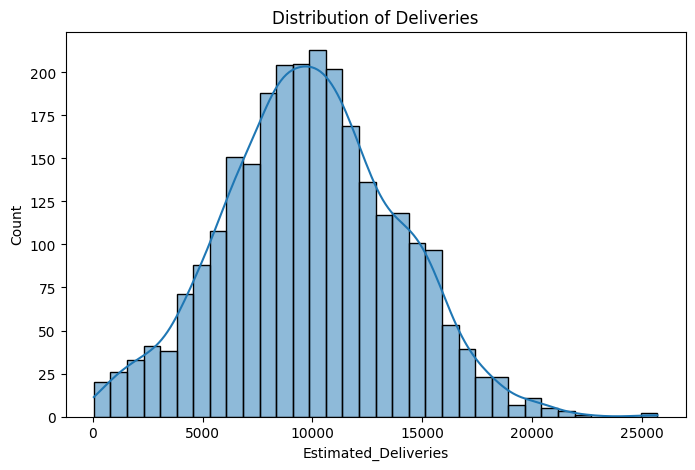

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.title("Distribution of Deliveries")
plt.show()

**Average Price by Model**

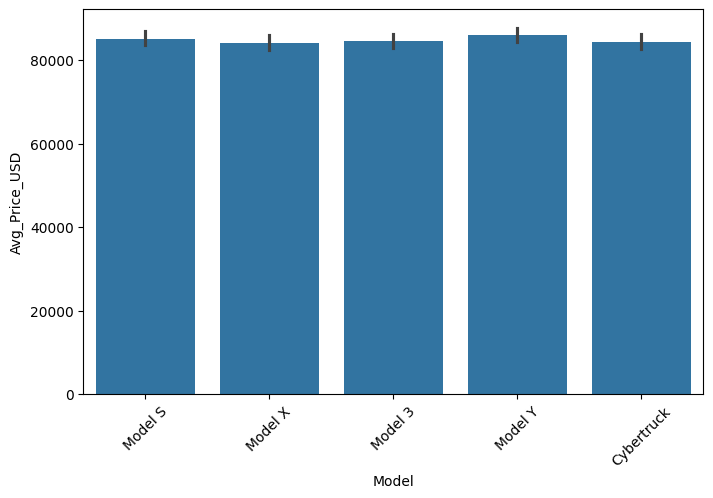

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="Model",
    y="Avg_Price_USD"
)
plt.xticks(rotation=45)
plt.show()

**Deliveries by Region**

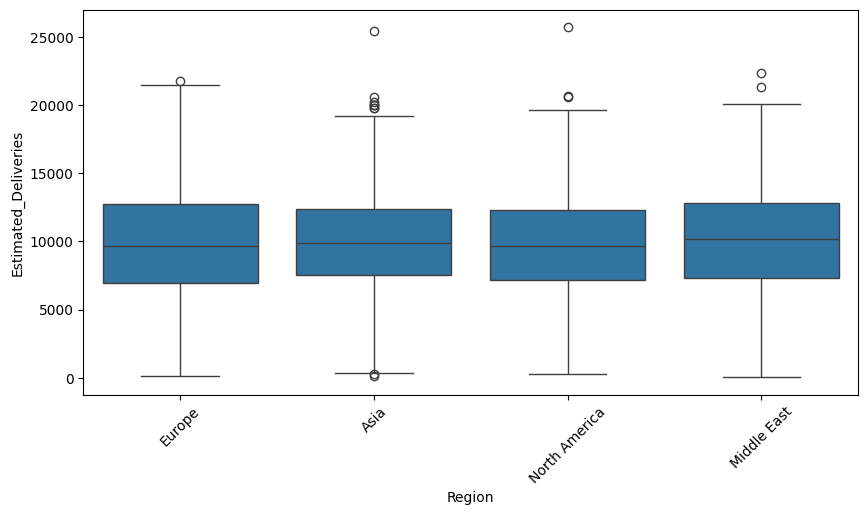

In [8]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)
plt.show()

**Correlation Matrix**

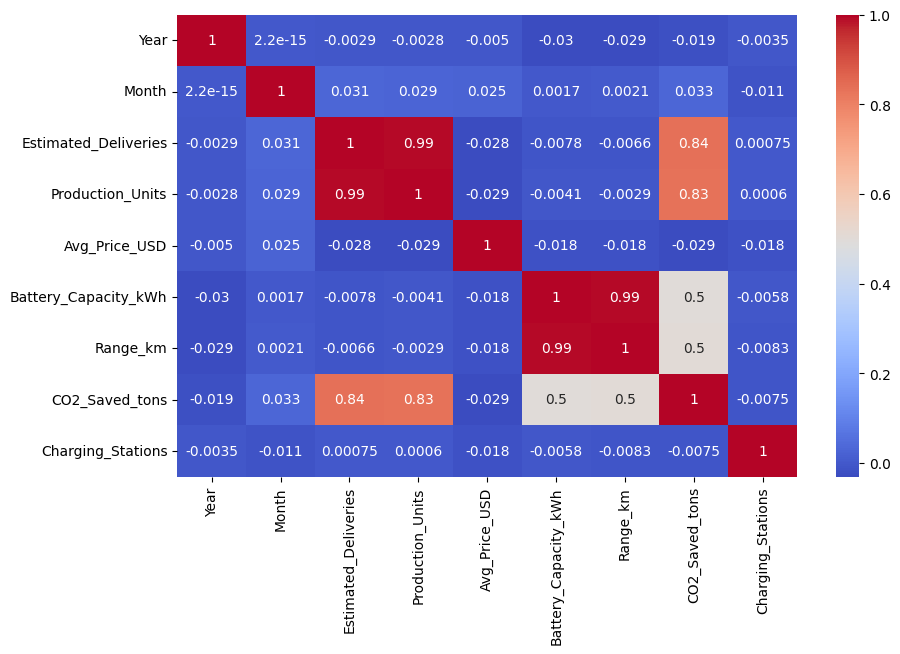

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

**Feature Engineering**

Create Date Column

In [10]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

Extract Features

In [11]:
df["Quarter"] = df["Date"].dt.quarter

df["Year_Month"] = (
    df["Year"]*100
    + df["Month"]
)

Production Efficiency

In [12]:
df["Production_Efficiency"] = (
    df["Estimated_Deliveries"]
    / df["Production_Units"]
)

Price per Kilometer

In [13]:
df["Price_per_km"] = (
    df["Avg_Price_USD"]
    / df["Range_km"]
)

**Regression Problem**

**Predict Deliveries**

Target:

In [14]:
y = df["Estimated_Deliveries"]

Features:

In [16]:
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)

**Separate Columns**

In [17]:
cat_cols = X.select_dtypes(
    include="object"
).columns

num_cols = X.select_dtypes(
    exclude="object"
).columns

**Build ML Pipeline**

In [18]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

**Train-Test Split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Linear Regression**

In [20]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

preds = lr_pipeline.predict(X_test)

**Evaluation**

In [21]:
print("MAE:",
      mean_absolute_error(y_test,preds))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,preds)))

print("R2:",
      r2_score(y_test,preds))

MAE: 108.9148762777078
RMSE: 153.893117859004
R2: 0.9984112012654159


**Random Forest Regression**

In [22]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

**Evaluate**

In [23]:
print("R2:",
      r2_score(y_test, rf_preds))

R2: 0.999139173359361


**Hyperparameter Tuning**

In [24]:
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,15],
    "model__min_samples_split":[2,5]
}

In [25]:
grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}


**Best Model**

In [26]:
best_model = grid.best_estimator_

best_preds = best_model.predict(X_test)

print(
    "Best R2:",
    r2_score(y_test,best_preds)
)

Best R2: 0.9991954225597282


**Time Series Forecasting**

Monthly Deliveries

In [27]:
ts = (
    df.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
    .sort_index()
)

**Plot**

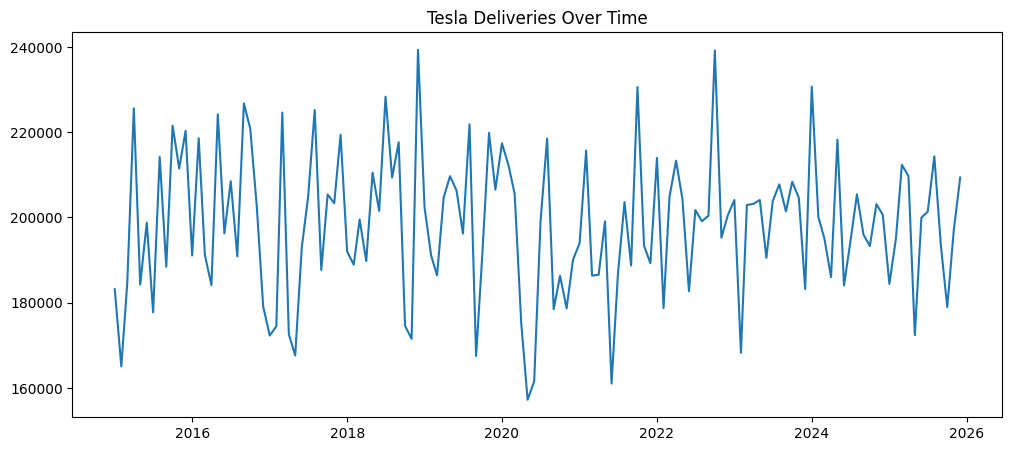

In [28]:
plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title(
    "Tesla Deliveries Over Time"
)

plt.show()


**Forecast**

In [29]:
model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


**Next 12 Months Forecast**

In [30]:
forecast = fit.forecast(12)

print(forecast)

2026-01-01    192503.413088
2026-02-01    190435.129208
2026-03-01    198070.502476
2026-04-01    189794.124276
2026-05-01    197737.023790
2026-06-01    192220.156886
2026-07-01    201206.012233
2026-08-01    208206.054814
2026-09-01    198374.685638
2026-10-01    203016.972600
2026-11-01    195870.464575
2026-12-01    206739.087753
Freq: MS, dtype: float64


**Visualization**

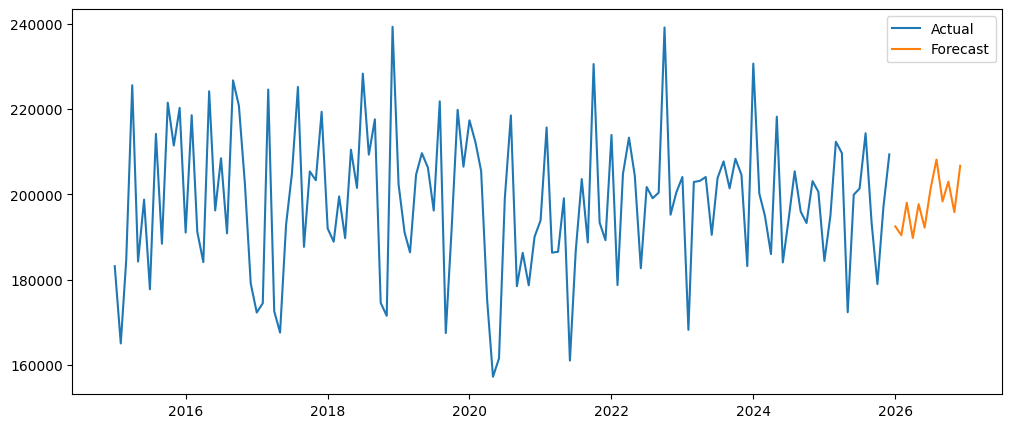

In [31]:
plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label="Actual"
)

plt.plot(
    forecast,
    label="Forecast"
)

plt.legend()
plt.show()

**Designed and implemented an end-to-end Machine Learning pipeline on Tesla deliveries and pricing data. The project included data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning using GridSearchCV, and time-series forecasting using Exponential Smoothing. The final model successfully predicted vehicle deliveries and provided future delivery forecasts, enabling data-driven business insights.**